In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42)


## 1. Device Configuration


In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load CIFAR-10 Dataset


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),   # Convert image to tensor
])

trainset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:16<00:00, 10.6MB/s]


In [ ]:
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size

train_dataset, val_dataset = random_split(
    trainset,
    [train_size, val_size]
)

## 3. Visualize CIFAR-10 Samples


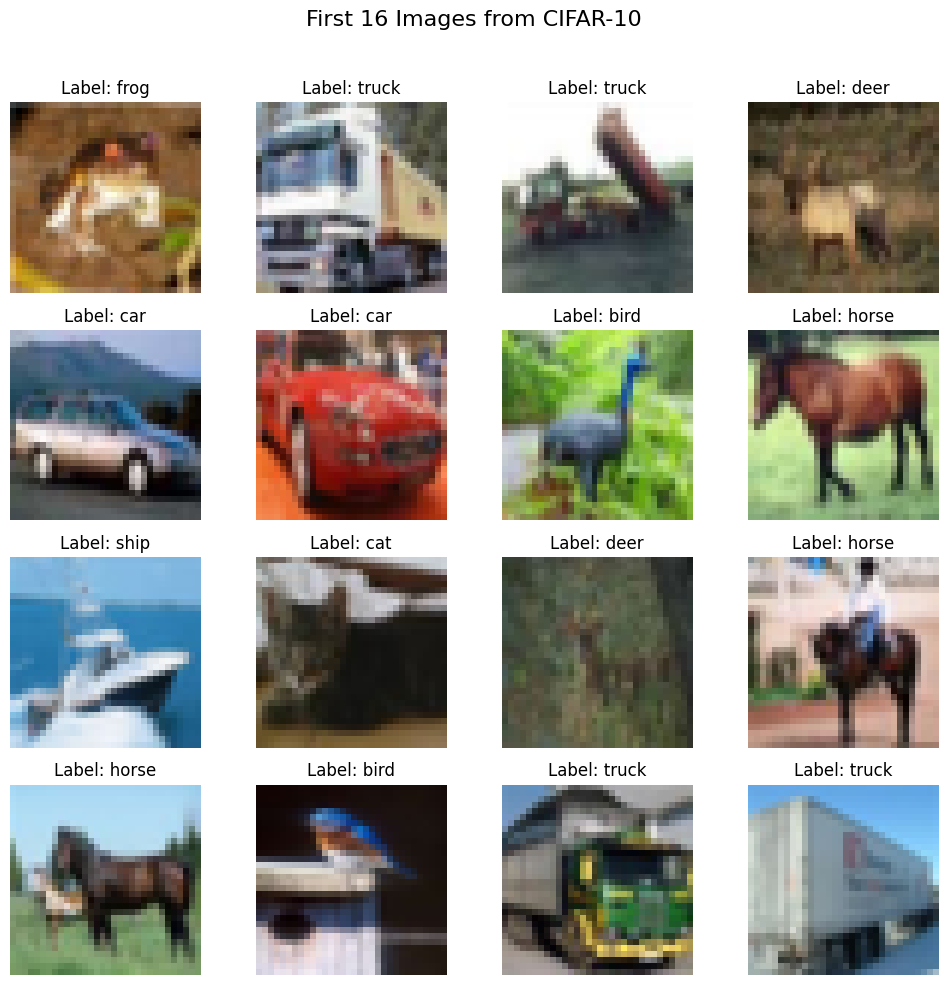

In [ ]:
import numpy as np

# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images from CIFAR-10", fontsize=16)

# Get class names for CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Plot the first 16 images from the trainset
for i, ax in enumerate(axes.flat):
    if i < len(trainset):
        img_tensor, label_idx = trainset[i]

        # Convert tensor to numpy array and rearrange dimensions for matplotlib (C, H, W) -> (H, W, C)
        img = img_tensor.permute(1, 2, 0).numpy()

        ax.imshow(img)  # Display image
        ax.axis('off')  # Remove axis for a cleaner look
        ax.set_title(f"Label: {classes[label_idx]}")  # Show the label
    else:
        ax.axis('off') # Hide empty subplots if less than 16 images

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

## 4. Dataset Split


In [ ]:

print(len(train_dataset))
print(len(val_dataset))
print(len(testset))

40000
10000
10000


## 5. DataLoaders


In [ ]:
from torch.utils.data import DataLoader

trainloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

valloader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

## 6. VGG16 Transfer Learning Model


In [ ]:
# Load the pre-trained VGG16 model
from torchvision.models import vgg16, VGG16_Weights

weights = VGG16_Weights.DEFAULT
vgg16 = vgg16(weights=weights)


### Freeze Pre-trained Feature Extractor


In [ ]:
for param in vgg16.features.parameters():
  param.requires_grad=False

### Replace the Classifier


In [ ]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 10)
)

In [ ]:
vgg16 = vgg16.to(device)

## 7. Training Configuration


In [ ]:
learning_rate = 0.0001
epochs = 10

## 7. Training Configuration


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=learning_rate)

## 9. Model Training and Validation


In [ ]:
# lists sirf ek baar banao
train_losses = []
val_losses = []

train_accs = []
val_accs = []


for epoch in range(epochs):

    # TRAINING
    vgg16.train()

    total_train_loss = 0
    correct_train = 0
    total_train_samples = 0

    for batch_features, batch_labels in trainloader:

        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = vgg16(batch_features)

        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total_train_samples += batch_labels.size(0)

        correct_train += (
            predicted == batch_labels
        ).sum().item()


    avg_train_loss = (
        total_train_loss /
        len(trainloader)
    )

    train_acc = (
        correct_train /
        total_train_samples
    )


    # VALIDATION
    vgg16.eval()

    total_val_loss = 0
    correct_val = 0
    total_val_samples = 0


    with torch.no_grad():

        for batch_features, batch_labels in valloader:

            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = vgg16(batch_features)

            loss = criterion(outputs, batch_labels)

            total_val_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total_val_samples += batch_labels.size(0)

            correct_val += (
                predicted == batch_labels
            ).sum().item()


    avg_val_loss = (
        total_val_loss /
        len(valloader)
    )

    val_acc = (
        correct_val /
        total_val_samples
    )


    # SAVE
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)


    print(
        f"Epoch {epoch+1}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1, Train Acc: 0.5414, Val Acc: 0.5931
Epoch 2, Train Acc: 0.5963, Val Acc: 0.6101
Epoch 3, Train Acc: 0.6187, Val Acc: 0.6219
Epoch 4, Train Acc: 0.6359, Val Acc: 0.6231
Epoch 5, Train Acc: 0.6523, Val Acc: 0.6302
Epoch 6, Train Acc: 0.6657, Val Acc: 0.6414
Epoch 7, Train Acc: 0.6835, Val Acc: 0.6337
Epoch 8, Train Acc: 0.6952, Val Acc: 0.6423
Epoch 9, Train Acc: 0.7103, Val Acc: 0.6427
Epoch 10, Train Acc: 0.7222, Val Acc: 0.6417


## 10. Test Evaluation


In [ ]:
# Evaluation on the CIFAR-10 test set
total = 0
correct = 0

vgg16.eval()
with torch.no_grad():
    for batch_features, batch_labels in testloader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = vgg16(batch_features)
        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


0.6411


## 11. Training Evaluation


In [ ]:
# Evaluation on the training set
total = 0
correct = 0

vgg16.eval()
with torch.no_grad():
    for batch_features, batch_labels in trainloader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = vgg16(batch_features)
        _, predicted = torch.max(outputs, 1)

        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

train_accuracy = correct / total
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")


0.790875


## 12. Training Curves


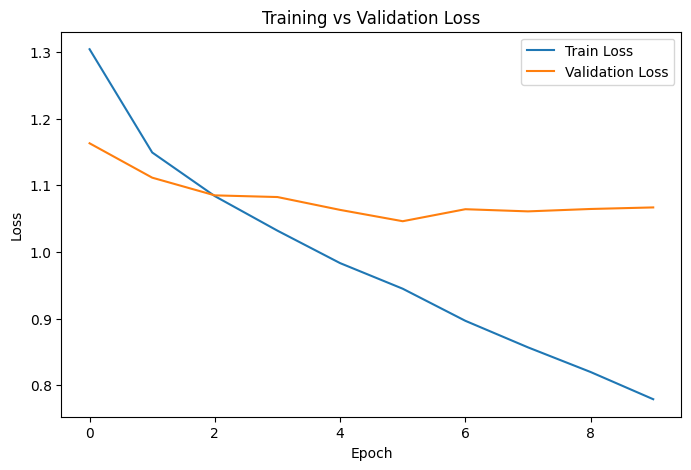

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

## 13. Accuracy Curves


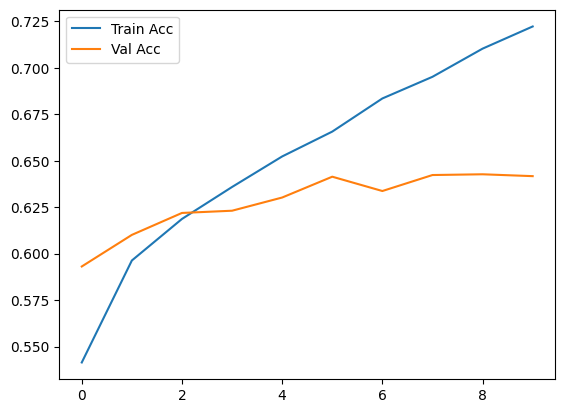

In [ ]:
plt.plot(train_accs)
plt.plot(val_accs)

plt.legend([
    "Train Acc",
    "Val Acc"
])

plt.show()

## Results

The recorded experiment in this notebook achieved:

| Metric | Result |
|---|---:|
| Training Accuracy | 72.22% |
| Validation Accuracy | 64.17% |
| Test Accuracy | 64.11% |
| Epochs | 10 |

These values are taken from the recorded notebook outputs.


## Conclusion

This project demonstrates transfer learning for CIFAR-10 image classification using a pre-trained VGG16 network. The convolutional feature extractor is frozen and a new fully connected classifier is trained for the 10 CIFAR-10 classes.
